# Naive Bayes
Bayesian statistics applied as a classification technique truly emerged in the 1960s to solve text information retrieval, though the underlying theory and early applications date back to the mid-1700s (Reverend Thomas Bayes). 

Naive Bayes is a generative statistical inference technique. Like other generative methods, it tries to estimate the Bayes optimal classifier by factoring the posterior into the likelihood and prior (see our repository's [README.md](../../../../README.md) and the classification [README.md](../../../README.md) for more). However, Naive Bayes takes this a step further by assuming its features are *class-conditionally independent*. This allows us to break down the Bayes optimal rule as follows:

$$
f(\vec{x}) = \text{argmax}_c (P(Y=y_c|\vec{x})) \\
P(Y=y_c|\vec{x}) = \frac{P(X=\vec{x}|y_c) \cdot P(y_c)}{P(\vec{x})} \\
P(X=\vec{x}|y_c) = P(x_1, x_2, ..., x_p | y_c) = \prod_{i=1}^p P(x_i|y_c)
$$

Here, we simply have to capture the independent class-conditional distributions for each feature individually and multiply them to estimate the joint distribution. In the real world, this is a heavy and often unrealistic bias, but it is computationally incredibly efficient.

Like our other generative methods, we can estimate the class prior $P(y_c)$ by its proportion in the training dataset. Since the marginal distribution of the sample $P(\vec{x})$ is a constant denominator across all classes, we can ignore it. Finally, by applying a log transformation (which is rank-preserving), we turn the multiplications into additions to prevent floating-point underflow and maintain computational integrity. This gives us our final, equivalent class score to optimize over:

$$
f(\vec{x}) = \text{argmax}_c \left( \log(P(y_c)) + \sum_{i=1}^p \log(P(x_i | y_c)) \right)
$$

In practice, we simply look at the data type of each individual feature to determine which likelihood distribution to apply. 

Because of our naive independence assumption, we don't have to calculate massive, multi-dimensional distributions. Instead:
*   For a **continuous feature**, we can assume it follows a single-variable (univariate) Gaussian distribution and compute its individual probability density $\text{pdf}_i(x_i)$.
*   For a **binary/boolean feature** (e.g., word presence), we use a simple Bernoulli probability $P(x_i | y_c)$.
*   For **count/frequency features** (e.g., word counts), we use a Multinomial probability.

Ultimately, we compute the log-likelihood for each feature independently, and simply sum them together along with the log of the class prior. This generates the final class score that we maximize to make our prediction.

For training we estimate the class specific distributions for each feature, then use those for inference.

### Guassian Features
The guassian distribution models continous random variables, and is common when measuring physical phenomena or asymptotic behavior of random variable parameters. For Naive Bayes we consider each continous random variable it's own class conditional gaussian:

$$
x \sim N(\mu, \sigma^2)
$$

It's likelihood is the following density function:

$$
\text{pdf}(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} e^{\frac{-1}{2\sigma^2} \cdot (x - \mu)^2}
$$

Using it in our classifier:

$$
f(x) = \text{argmax}_c (\frac{1}{\sqrt{2 \pi \sigma_c^2}} e^{\frac{-1}{2\sigma_c^2} \cdot (x - \mu_c)^2} \cdot P(y_c))
$$

Applying the rank perserving log for stability:

$$
f(x) = \text{argmax}_c (\log(\frac{1}{\sqrt{2 \pi \sigma_c^2}}) + \frac{-1}{2\sigma_c^2} \cdot (x - \mu_c)^2 + \log(P(y_c)))
$$

In [2]:
import numpy as np

class_1_data = np.random.normal(5, 3, (1000, 1))
class_0_data = np.random.normal(-5,1, (1000, 1))

dataset = np.concat([np.concat([class_0_data, np.zeros(shape=(1000,1))], axis=-1),np.concat([class_1_data, np.ones(shape=(1000,1))], axis=-1)], axis=0)

np.random.shuffle(dataset)

training_dataset = dataset[:int(dataset.shape[0]*.8)]
test_dataset = dataset[int(dataset.shape[0]*.8):]

len(test_dataset), len(training_dataset)

(400, 1600)

In [3]:
class NaiveBayesClassifierGaussianBinarySingleVariable:
    def __init__(self):
        self.label_0_mean = None
        self.label_1_mean = None
        self.label_0_var = None
        self.label_1_var = None
        self.label_1_prior = None
        self.label_0_prior = None

    def train(self, dataset):
        '''
        Assumes last column is binary label
        '''
        label_1_data = dataset[dataset[:, -1] == 1][:, :-1]
        label_0_data = dataset[dataset[:, -1] == 0][:, :-1]

        self.label_1_mean = label_1_data.mean(axis=0)
        self.label_0_mean = label_0_data.mean(axis=0)

        self.label_1_var = label_1_data.var(axis=0)
        self.label_0_var = label_0_data.var(axis=0)

        self.label_1_prior = len(label_1_data) / len(dataset)
        self.label_0_prior = len(label_0_data) / len(dataset)


    def predict(self, data):
        if self.label_0_mean is None:
            raise Exception("Cannot predict without training.")
        class_1_score = np.log( 1 / np.sqrt(2*np.pi * self.label_1_var)) - 1 / (2 * self.label_1_var) * (data - self.label_1_mean)**2 + np.log(self.label_1_prior)
        class_0_score = np.log( 1 / np.sqrt(2*np.pi * self.label_0_var)) - 1 / (2 * self.label_0_var) * (data - self.label_0_mean)**2 + np.log(self.label_0_prior)
        return (class_1_score > class_0_score).astype(int).reshape(-1)

guassian_classifer = NaiveBayesClassifierGaussianBinarySingleVariable()
guassian_classifer.train(training_dataset)
print(guassian_classifer.__dict__)
(guassian_classifer.predict(test_dataset[:, :-1]) == test_dataset[:, -1]).mean()

{'label_0_mean': array([-4.96073714]), 'label_1_mean': array([4.93604557]), 'label_0_var': array([1.04982309]), 'label_1_var': array([9.46076092]), 'label_1_prior': 0.5, 'label_0_prior': 0.5}


np.float64(0.9925)

We were able to recover the original data producing parameters, and classify with the near (as good as our estimate) bayes optimal rule.

### Bernoulli Features
Bernoulli distribution models binary outcomes with a probability that its 1 (by convention), the alternative is always $1 - p$.
If a feature $X$ follows a Bernoulli distribution with probability $p$, we denote this as:
$$
X \sim \text{Bernoulli}(p)
$$

1. The Piecewise Form (Logical)
The most intuitive way to write this PMF is as a logical map, evaluating the two possible discrete outcomes:
$$
P(X=x) = \begin{cases} 
p & \text{if } x = 1 \\
1-p & \text{if } x = 0 
\end{cases}
$$

2. The Closed Form (Algebraic)
To use this in machine learning (specifically so we can apply a log transformation), we collapse the piecewise logic into a single, compact algebraic equation using exponents:
$$
P(X=x) = p^x(1-p)^{1-x}
$$


So plugging this into our classifier (Maximum A Posteriori (MAP)):

$$
f(x) = \text{argmax}_c (p_c^x \cdot (1 - p_c)^{1-x} \cdot P(y_c))
$$

Where $p_c$ is the class conditional probability of the outcome of 1. With the usual log trick:

$$
f(x) = \text{argmax}_c (x \log(p_c) +(1-x) \log(1 - p_c) + \log(P(y_c)))
$$

In [4]:
class_0_data = np.random.binomial(1, 0.1, (1000, 1))
class_1_data = np.random.binomial(1, 0.8, (1000, 1))

dataset = np.concat([np.concat([class_0_data, np.zeros_like(class_0_data)], axis=1), np.concat([class_1_data, np.ones_like(class_1_data)], axis=1)],axis=0)
np.random.shuffle(dataset)

training_dataset = dataset[:int(dataset.shape[0]*0.8)]
test_dataset = dataset[int(dataset.shape[0]*0.8):]

class NaiveBayesClassifierBernoulliBinarySingleVariable():
    def __init__(self):
        self.class_0_p = None
        self.class_0_prior = None
        self.class_1_p = None
        self.class_1_prior = None
    def train(self, dataset):
        self.class_0_p = dataset[dataset[:, -1] == 0][:, :-1].mean()
        self.class_0_prior = len( dataset[dataset[:, -1] == 0]) / len(dataset)

        self.class_1_p = dataset[dataset[:, -1] == 1][:, :-1].mean()
        self.class_1_prior = len( dataset[dataset[:, -1] == 1]) / len(dataset)

    def predict(self, data):
        if self.class_0_p is None:
            raise Exception("Cannot predict without training")
        class_0_score = np.log(self.class_0_prior) + data * np.log(self.class_0_p) + (1 - data) * np.log(1 - self.class_0_p)
        class_1_score = np.log(self.class_1_prior) + data * np.log(self.class_1_p) + (1 - data) * np.log(1 - self.class_1_p)
        return (class_1_score > class_0_score).reshape(-1)

model = NaiveBayesClassifierBernoulliBinarySingleVariable()
model.train(training_dataset)
print(model.__dict__)
(model.predict(test_dataset[:, :-1]) == test_dataset[:, -1]).mean()

{'class_0_p': np.float64(0.08944099378881988), 'class_0_prior': 0.503125, 'class_1_p': np.float64(0.8075471698113208), 'class_1_prior': 0.496875}


np.float64(0.8375)

We were able to recover the original data producing parameters, and classify with the near (as good as our estimate) bayes optimal rule. To prevent overflow in the eventual application we may want to add laplace smoothing (+1 to prior and probability counts to avoid $\log(0)$).

### Multinomial Features
The multinomial distribution assigns a probability to a vector of event counts (integers), $P(\vec{x})$, using a probability mass function based on the outcome probabilities of single events ($\vec{p}$). It does this using combinatorics:

$$
P(\vec{x}) = \frac{N!}{\prod_{i=1}^p x_i!} \cdot \prod_{i=1}^p p_i^{x_i}
$$

This scales the probability of seeing that exact quantity of events by the number of combinatorial ways to arrange those events.

Because this combinatorial weight $\left( \frac{N!}{\prod_{i=1}^p x_i!} \right)$ (which is the unique ways to arrange the sequence of the events (total! / repeating!)) depends only on the new document and is constant across all classes, it can be factored out and ignored when maximizing the class conditional likelihood. After applying a log transformation (which is rank-preserving/monotonic) for computational stability, we get our equivalent function to maximize:

$$
f(\vec{x}) = \text{argmax}_c (P(\vec{x} | y_c) \cdot P(y_c)) \\
= \text{argmax}_c \left( \frac{N!}{\prod_{i=1}^p x_i!} \cdot \prod_{i=1}^p p_{ci}^{x_i} \cdot P(y_c) \right) \\
= \text{argmax}_c \left( \sum_{i=1}^p x_i \log(p_{ci}) + \log(P(y_c)) \right)
$$

To get the learned parameter $\vec{p}_c$ during training:

$$
p_{ic} = \frac{N_{ic}}{N_c}
$$

Here, you treat all of a class's samples as one giant pooled event, and calculate the proportion (from base all feature counts summed up for a given class) of each feature's frequency to get its probability. 

When you treat a set of features this way, you are assuming that their specific order does not matter (e.g., the "bag-of-words" model), as implicit in the multinomial distribution.

In [5]:
class_0_data = np.random.multinomial(10, [0.1, 0.05, 0.25, 0.5, .1], (1000)).astype(int)
class_1_data = np.random.multinomial(10, [0.32, 0.15, 0.03, 0.25, 0.25], (1000)).astype(int)

dataset = np.concat([np.concat([class_0_data, np.zeros(shape=(1000, 1),dtype=int)], axis=1), np.concat([class_1_data, np.ones(shape=(1000,1),dtype=int)], axis=1)], axis=0)

np.random.shuffle(dataset)

training_dataset = dataset[:int(len(dataset)*.8)]
test_dataset = dataset[int(len(dataset)*.8):]


In [6]:
class NaiveBayesMultinomialBinary():
    def __init__(self):
        self.class_0_probabilities = None
        self.class_1_probabilities = None
        self.class_0_prior = None
        self.class_1_prior = None
    def train(self, dataset):
        class_0_data = dataset[dataset[:, -1] == 0][:, :-1]
        class_1_data = dataset[dataset[:, -1] == 1][:, :-1]
        counts_0 = np.sum(class_0_data, axis=0)
        counts_1 = np.sum(class_1_data, axis=0)

        self.class_0_probabilities = counts_0 / np.sum(counts_0)
        self.class_1_probabilities = counts_1 / np.sum(counts_1)

        self.class_0_prior = len(class_0_data) / len(dataset)
        self.class_1_prior = len(class_1_data) / len(dataset)
    def predict(self, data):
        if self.class_0_probabilities is None:
            raise Exception("Cannot predict without being trained.")
        class_0_score = data @ np.log(self.class_0_probabilities) + np.log(self.class_0_prior)
        class_1_score = data @ np.log(self.class_1_probabilities) + np.log(self.class_1_prior)
        return (class_1_score > class_0_score).astype(int).reshape(-1)

model = NaiveBayesMultinomialBinary()

model.train(training_dataset)
print(model.__dict__)
(model.predict(test_dataset[:, :-1]) == test_dataset[:, -1]).mean()


{'class_0_probabilities': array([0.10075758, 0.05189394, 0.25467172, 0.49608586, 0.09659091]), 'class_1_probabilities': array([0.32017327, 0.14814356, 0.0279703 , 0.24863861, 0.25507426]), 'class_0_prior': 0.495, 'class_1_prior': 0.505}


np.float64(0.9725)

Near optimal inference performance (given our parameter estimates were pretty close to the truth). 

### Multivariate Naive Bayes
The naive assumption let's us combine log posteriors in an additive way which greatly simplifies the problem.

$$
f(x) = \argmax_c(\log(P(y_c)) + \sum_{i}^{p}\log(P(x_i|y_c)))
$$

So simply to classify multivariate samples, we sum the pre prior equivalent scores (remove added constants as needed) no matter the variable, and estimate parameters needed for classification independently.

In [7]:
import pandas as pd
# 3 Bernoulli features
class_0_binary_data = np.random.binomial(1, [0.26, 0.12, 0.13], (1000, 3))
class_1_binary_data = np.random.binomial(1, [0.90, 0.25, 0.69], (1000, 3))


# 3 Gaussian features
class_0_gaussian_data = np.random.normal(loc=[-3, 12, 4], scale=[5, 1, .3],size=(1000, 3))
class_1_gaussian_data = np.random.normal(loc=[-1, 3, 6], scale=[12, .2, 4],size=(1000, 3))

# a multinomial feature
class_0_multinomial_data = np.random.multinomial(10, [0.32, 0.44, 0.11, 0.14], size=(1000))
class_1_multinomial_data = np.random.multinomial(10, [0.01, 0.32, 0.64, 0.03], size=(1000))

class_0_data = np.concat([class_0_binary_data, class_0_gaussian_data, class_0_multinomial_data, np.zeros((1000, 1))], axis=1)
class_1_data = np.concat([class_1_binary_data, class_1_gaussian_data, class_1_multinomial_data, np.ones((1000, 1))], axis=1)

dataset = np.concat([class_0_data, class_1_data], axis=0)
np.random.shuffle(dataset)

df = pd.DataFrame(dataset, columns=["Binary1", "Binary2", "Binary3", "Gaussian1", "Gaussian2", "Gaussian3", "Multionimal1", "Multionimal2", "Multionimal3", "Multionimal4", "Label"])

In [8]:
df.head()

,Binary1,Binary2,Binary3,Gaussian1,Gaussian2,Gaussian3,Multionimal1,Multionimal2,Multionimal3,Multionimal4,Label
0,0.0,0.0,0.0,-5.702468,12.433565,4.121265,2.0,5.0,1.0,2.0,0.0
1,0.0,0.0,1.0,0.025218,11.257787,4.002193,3.0,4.0,1.0,2.0,0.0
2,0.0,0.0,0.0,6.023697,14.534846,4.411496,4.0,2.0,1.0,3.0,0.0
3,0.0,0.0,0.0,-0.993381,10.490183,3.669742,5.0,3.0,2.0,0.0,0.0
4,0.0,0.0,0.0,-8.566843,12.846490,3.615899,3.0,6.0,1.0,0.0,0.0


In [9]:
index = int(len(df)*.8)
training_dataset = df[:index]
test_dataset = df[index:]

In [10]:
class MultivariateNaiveBayesBinary():
    def __init__(self, binary_column_names=[], gaussian_column_names=[], multinomial_column_names=[], label_column_name="Label"):
        self.binary_column_names = binary_column_names
        self.gaussian_column_names = gaussian_column_names
        self.multinomial_column_names = multinomial_column_names
        self.label_column_name = label_column_name

        self.class_0_prior = None
        self.class_1_prior = None

        self.binary_parameters = {binary_column_name: {
            "class_1_p": None,
            "class_0_p": None
        } for binary_column_name in self.binary_column_names}

        self.gaussian_parameters = {gaussian_column_name: {
            "class_0_mean": None,
            "class_0_var": None,
            "class_1_mean": None,
            "class_1_var": None,
        } for gaussian_column_name in self.gaussian_column_names}

        self.multinomial_parameters = {multinomial_column_name: {
            "p_1": None,
            "p_0": None
        } for multinomial_column_name in self.multinomial_column_names}

    def train(self, training_dataset: pd.DataFrame):
        self.class_1_prior = training_dataset[self.label_column_name].mean()
        self.class_0_prior = 1 - self.class_1_prior

        for binary_column_name in self.binary_column_names:
            binary_p_c1 = training_dataset[training_dataset[self.label_column_name] == 1][binary_column_name].mean()
            binary_p_c0 = training_dataset[training_dataset[self.label_column_name] == 0][binary_column_name].mean()
            self.binary_parameters[binary_column_name] = {
                "class_1_p" : binary_p_c1,
                "class_0_p" : binary_p_c0
            }

        for gaussian_column_name in self.gaussian_column_names:
            mean_class_1 = training_dataset[training_dataset[self.label_column_name] == 1][gaussian_column_name].mean()
            mean_class_0 = training_dataset[training_dataset[self.label_column_name] == 0][gaussian_column_name].mean()
            var_class_1 = training_dataset[training_dataset[self.label_column_name] == 1][gaussian_column_name].var()
            var_class_0 = training_dataset[training_dataset[self.label_column_name] == 0][gaussian_column_name].var()
            self.gaussian_parameters[gaussian_column_name] = {
                "class_0_mean": mean_class_0,
                "class_0_var": var_class_0,
                "class_1_mean": mean_class_1,
                "class_1_var": var_class_1,
            }
        
        total_frequency_class_0 = training_dataset[training_dataset[self.label_column_name] == 0][self.multinomial_column_names].sum().sum()
        total_frequency_class_1 = training_dataset[training_dataset[self.label_column_name] == 1][self.multinomial_column_names].sum().sum()
        for multinomial_column_name in self.multinomial_column_names:
             p_1 = training_dataset[training_dataset[self.label_column_name] == 1][multinomial_column_name].sum() / total_frequency_class_1
             p_0 = training_dataset[training_dataset[self.label_column_name] == 0][multinomial_column_name].sum() / total_frequency_class_0
             self.multinomial_parameters[multinomial_column_name] = {
                "p_1": p_1,
                "p_0": p_0
             }
    def predict(self, data):
        score_0 = 0
        score_1 = 0

        for binaryColumn in self.binary_column_names:
            score_0 += data[binaryColumn] * np.log(self.binary_parameters[binaryColumn]["class_0_p"]) + (1 - data[binaryColumn]) * np.log(1 - self.binary_parameters[binaryColumn]["class_0_p"])
            score_1 += data[binaryColumn] * np.log(self.binary_parameters[binaryColumn]["class_1_p"]) + (1 - data[binaryColumn]) * np.log(1 - self.binary_parameters[binaryColumn]["class_1_p"])

        for gaussianColumn in self.gaussian_column_names:
            score_0 += np.log(1 / np.sqrt(2 * np.pi * self.gaussian_parameters[gaussianColumn]["class_0_var"])) - 1 / (2 * self.gaussian_parameters[gaussianColumn]["class_0_var"]) * (data[gaussianColumn] - self.gaussian_parameters[gaussianColumn]["class_0_mean"])**2
            score_1 += np.log(1 / np.sqrt(2 * np.pi * self.gaussian_parameters[gaussianColumn]["class_1_var"])) - 1 / (2 * self.gaussian_parameters[gaussianColumn]["class_1_var"]) * (data[gaussianColumn] - self.gaussian_parameters[gaussianColumn]["class_1_mean"])**2

        multinomial_p_1 = np.array([self.multinomial_parameters[x]["p_1"] for x in self.multinomial_parameters])
        multinomial_p_0 = np.array([self.multinomial_parameters[x]["p_0"] for x in self.multinomial_parameters])
        score_1 += data[self.multinomial_column_names] @ np.log(multinomial_p_1)
        score_0 += data[self.multinomial_column_names] @ np.log(multinomial_p_0)

        score_0 += np.log(self.class_0_prior)
        score_1 += np.log(self.class_1_prior)
        return (score_1 > score_0)


model = MultivariateNaiveBayesBinary(binary_column_names=["Binary1", "Binary2", "Binary3"], multinomial_column_names=["Multionimal1", "Multionimal2", "Multionimal3", "Multionimal4"], gaussian_column_names=["Gaussian1", "Gaussian2", "Gaussian3"])
model.train(training_dataset=training_dataset)
model.__dict__

{'binary_column_names': ['Binary1', 'Binary2', 'Binary3'],
 'gaussian_column_names': ['Gaussian1', 'Gaussian2', 'Gaussian3'],
 'multinomial_column_names': ['Multionimal1',
  'Multionimal2',
  'Multionimal3',
  'Multionimal4'],
 'label_column_name': 'Label',
 'class_0_prior': np.float64(0.504375),
 'class_1_prior': np.float64(0.495625),
 'binary_parameters': {'Binary1': {'class_1_p': np.float64(0.8965952080706179),
   'class_0_p': np.float64(0.2577447335811648)},
  'Binary2': {'class_1_p': np.float64(0.2698612862547289),
   'class_0_p': np.float64(0.10037174721189591)},
  'Binary3': {'class_1_p': np.float64(0.6569987389659521),
   'class_0_p': np.float64(0.1127633209417596)}},
 'gaussian_parameters': {'Gaussian1': {'class_0_mean': np.float64(-3.1470830463440764),
   'class_0_var': np.float64(24.27140815398088),
   'class_1_mean': np.float64(-1.4788271388397374),
   'class_1_var': np.float64(149.82168743610828)},
  'Gaussian2': {'class_0_mean': np.float64(11.990883825467364),
   'class_0

In [11]:
(model.predict(test_dataset.drop(columns=["Label"]).astype(int)) == test_dataset["Label"]).mean()

np.float64(1.0)

So with the multivariate hetergenously distributed random variables we can get the near optimal classifier (if our assumptions hold true), limited only by the variability in our parameter estimation.

## The Two Goals
When we look at applying Naive Bayes, the two classic goals of statistical inference arise: interpretability (drawing inferences from the data) and inference performance (optimizing generalization error).

### Interpretability of Naive Bayes
Naive Bayes has the following tests and properties that can be used for interpretation:

1. **Probability Calibration:** A probability score can be derived by using Softmax on the final class scores:
    $$
    p(y_c | \vec{x}) = \frac{e^{\text{score}_c}}{\sum_i^C e^{\text{score}_i}}
    $$
    Since our estimate of the posterior is only as good as our estimate of the joint likelihood, our assumption of independence must hold perfectly for these probabilities to be mathematically true. **We must test for independence and good fits for our feature distributions.**

2. **Feature Importance (Log-Likelihood Ratio):** For a particular feature, we can derive its multiplicative effect on the decision boundary by looking at the log-ratio of its class-conditional probabilities:
    $$
    \text{effect}_{i} = \log\left(\frac{P(x_i | y_1)}{P(x_i | y_0)}\right)
    $$
    If this ratio is exactly 0, the feature provides no predictive value. For this to hold true, our assumption of independence and our feature distributions must be valid, since that is where those coefficients come from. **We must test for independence and good fits for our feature distributions.**

3. **Hypothesis Testing for Significance:** Because we calculate the explicit distribution parameters for each class (e.g., $\mu_0$ vs $\mu_1$, or $p_0$ vs $p_1$), we can run standard statistical hypothesis tests to determine if a feature actually matters. We can use a **Two-Sample T-Test** for our Gaussian features or a **Chi-Square Test of Independence** for our discrete features to prove if the distributions between Class 0 and Class 1 are statistically significantly different. Since we're testing one feature at a time, feature independence is not required but **does require good fits for our feature distributions.**

4. **Generative Sampling:** Because Naive Bayes is a generative model, we have completely recovered the original data-producing parameters. We can sample from our learned parameters to generate synthetic data rows, assuming our distribution is correct. **We must test for independence and good fits for our feature distributions.**

#### Testing Assumptions
So for most if not all of these need to test for feature independence and for good fits for our feature distributions.

For goodness of fit, discrete features like bernoulli feaures or multinomial features dont have tests, by defintion we know the finite values they can take and probability of taking those values, so there's no ambiguity, there is no alternative continuous "shape" it could possibly take.

For our Gaussian features we can check for normality via skewness (center of mass) and kurtosis (tail fatness) in standard statistical tests.


In [12]:
from scipy import stats

test_feature = class_0_gaussian_data[:, 0]

skewness = stats.skew(test_feature)
kurtosis = stats.kurtosis(test_feature)

k_stat, k_p_value = stats.normaltest(test_feature)

sw_stat, sw_p_value = stats.shapiro(test_feature)

print(f"Skewness: {skewness} | Kurtosis: {kurtosis}")
print(f"D'agostino p-value: {k_p_value}")
print(f"Shapiro-Wil p-value: {sw_p_value}")

Skewness: -0.006397896532920081 | Kurtosis: 0.023582034697232857
D'agostino p-value: 0.9618775391329526
Shapiro-Wil p-value: 0.3650052165536364


As expected with our normally generated data we fail to reject the null hypothesis that it's Gaussian.

In [53]:
data = np.random.exponential(2, (1000, 1))

_, p_value = stats.normaltest(data)
p_value

array([3.86350027e-100])

In an exponential feature we can see the test detects non normality. You can try to model as an exponential with it's distribuiton function.

For feature independence, we evaluate pairs of features. If two features are truly conditionally independent, their joint probability perfectly equals the product of their individual marginal probabilities:

$$P(X_1, X_2 \mid Y) = P(X_1 \mid Y) P(X_2 \mid Y)$$

When we discussed entropy in our [classification readme](../../README.md) (see more there), we defined it as the "average surprise." Surprise relates to the optimal encoding length of an event to reduce average signal length—an inverse relationship with its probability.

To quantify how well our data fits the Naive Bayes assumption, we use **Mutual Information (MI)**. MI measures the reduction in surprise (uncertainty) about one variable when we observe another. If two variables are completely independent, observing one reduces zero surprise about the other, yielding a score of 0.

How do we measure this exact difference between the true joint distribution and our assumed independent distribution? We use **Kullback-Leibler (KL) Divergence**, which quantifies the extra "bits" of information we incur by falsely assuming we can use the product of the marginals instead of the true joint distribution:

$$\text{Mutual Information}(X_1, X_2) = D_{KL}(P(X_1, X_2) \parallel P(X_1) P(X_2))$$
$$= \sum_{x_1, x_2} P(x_1, x_2) \log \left( \frac{P(x_1, x_2)}{P(x_1) P(x_2)} \right)$$

To normalize this metric into a bounded $0$ to $1$ score, we divide that reduction in entropy by the maximum entropy of the variables under consideration. 

$$\text{Normalized Mutual Information}(X_1, X_2) = \frac{\sum_{x_1, x_2} P(x_1, x_2) \log \left( \frac{P(x_1, x_2)}{P(x_1) P(x_2)} \right)}{\max(H(X_1), H(X_2))}$$

*(Where standard entropy is $H(X) = - \sum_{x} P(x) \log P(x)$)*

Because Naive Bayes relies on conditional independence, we simply condition these distributions on our class label $Y$. The fully **Normalized Conditional Mutual Information (NCMI)** is the prior-weighted sum of this normalized distance across all classes:

$$\text{NCMI}(X_1, X_2) = \sum_{c} P(y_c) \left[ \frac{\sum_{x_1, x_2} P(x_1, x_2 \mid y_c) \log \left( \frac{P(x_1, x_2 \mid y_c)}{P(x_1 \mid y_c) P(x_2 \mid y_c)} \right)}{\max(H(X_1 \mid y_c), H(X_2 \mid y_c))} \right]$$

**Handling Continuous Features**
While this formulation applies directly to discrete distributions with finite states, continuous features require **differential entropy** ($\int p(x) \log p(x) dx$), replacing probability masses with density integrals. Because integrating empirical tabular data analytically is intractable, practical implementations rely on density estimation. For example, `scikit-learn` uses the non-parametric **Kraskov K-Nearest Neighbors (KNN) Estimator**, which estimates local probability density directly from the geometric distances between nearest neighbors.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

def calculate_normalized_cmi(df, label_column="Label"):
    features = df.columns.drop(label_column)
    p_y1 = df[label_column].mean()
    p_y0 = 1.0 - p_y1

    n_feat = len(features)
    raw_cmi = np.zeros((n_feat, n_feat))
    
    discrete_mask = [df[col].nunique() < 20 for col in features]
    
    df_0 = df[df[label_column] == 0]
    df_1 = df[df[label_column] == 1]
    
    for i, target_col in enumerate(features):
        is_discrete = discrete_mask[i]
        mi_func = mutual_info_classif if is_discrete else mutual_info_regression
        
        mi_0 = mi_func(df_0[features], df_0[target_col], discrete_features=discrete_mask, random_state=42)
        mi_1 = mi_func(df_1[features], df_1[target_col], discrete_features=discrete_mask, random_state=42)
        
        raw_cmi[:, i] = (p_y0 * mi_0) + (p_y1 * mi_1)
    
    # 1. Clamp negative KNN estimation noise to 0
    raw_cmi = np.maximum(raw_cmi, 0)
    
    # 2. Symmetrize matrix: 0.5 * (M + M^T)
    raw_cmi = (raw_cmi + raw_cmi.T) / 2.0
    
    # 3. Geometric mean normalization: CMI / sqrt(H_A * H_B)
    entropies = np.diag(raw_cmi)
    normalization_matrix = np.sqrt(np.outer(entropies, entropies))
    normalization_matrix[normalization_matrix == 0] = 1e-9
    
    normalized_matrix = raw_cmi / normalization_matrix
    np.fill_diagonal(normalized_matrix, 1.0)
    
    return pd.DataFrame(normalized_matrix, index=features, columns=features)

ncmi_df = calculate_normalized_cmi(df, label_column="Label")
ncmi_df.style.background_gradient(cmap='Reds', axis=None).format("{:.3f}")

,Binary1,Binary2,Binary3,Gaussian1,Gaussian2,Gaussian3,Multionimal1,Multionimal2,Multionimal3,Multionimal4
Binary1,1.000,0.000,0.002,0.003,0.004,0.003,0.005,0.005,0.004,0.003
Binary2,0.000,1.000,0.000,0.000,0.002,0.002,0.002,0.005,0.005,0.003
Binary3,0.002,0.000,1.000,0.000,0.008,0.000,0.004,0.005,0.006,0.002
Gaussian1,0.003,0.000,0.000,1.000,0.003,0.000,0.006,0.001,0.009,0.000
Gaussian2,0.004,0.002,0.008,0.003,1.000,0.003,0.000,0.004,0.005,0.002
Gaussian3,0.003,0.002,0.000,0.000,0.003,1.000,0.002,0.001,0.000,0.001
Multionimal1,0.005,0.002,0.004,0.006,0.000,0.002,1.000,0.108,0.025,0.035
Multionimal2,0.005,0.005,0.005,0.001,0.004,0.001,0.108,1.000,0.332,0.033
Multionimal3,0.004,0.005,0.006,0.009,0.005,0.000,0.025,0.332,1.000,0.018
Multionimal4,0.003,0.003,0.002,0.000,0.002,0.001,0.035,0.033,0.018,1.000


Across distinct feature families, the normalized conditional mutual information remains well within the noise floor (≤0.009), confirming cross-feature conditional independence.

The moderate score between Multinomial2 and Multinomial3 (0.332) reflects the natural negative covariance inherent to multinomial trials, where bin counts are constrained by a fixed sum. When treating the multinomial vector as a single generative block, the naive assumption holds cleanly. For standard features, any pairwise score exceeding 0.30 indicates problematic redundancy requiring feature pruning, combination, or dimensionality reduction.

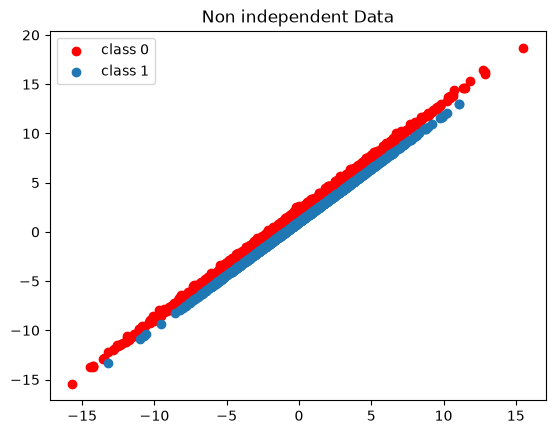

In [57]:
import numpy as np
import matplotlib.pyplot as plt
base_covar_0 = np.random.uniform(3, 4, (2,2))
base_covar_1 = np.random.uniform(2, 3, (2,2))
data_0 = np.concat([np.random.multivariate_normal([-1, 1], base_covar_0 @ base_covar_0.T, size=(1000)), np.zeros((1000, 1), dtype=int)], axis=1)
data_1 = np.concat([np.random.multivariate_normal([0, 1], base_covar_1 @ base_covar_1.T, size=(1000)), np.ones((1000, 1), dtype=int)], axis=1)
plt.scatter(data_0[:, 0], data_0[:, 1], c="red", label="class 0")
plt.scatter(data_1[:, 0], data_1[:, 1], label="class 1")
plt.legend()
plt.title("Non independent Data")
plt.show()


In [58]:
df = pd.DataFrame(
    np.concat([data_0, data_1], axis=0),
    columns=["Feature1", "Feature2", "Label"]
)
df.head()


,Feature1,Feature2,Label
0,-7.939014,-6.639244,0.0
1,-7.715013,-6.434443,0.0
2,-1.568785,0.259707,0.0
3,4.897214,7.345788,0.0
4,-6.697882,-5.233378,0.0


In [59]:
df_cmi = calculate_normalized_cmi(df)
df_cmi.style.background_gradient(cmap='Reds', axis=None).format("{:.3f}")

,Feature1,Feature2
Feature1,1.000,0.756
Feature2,0.756,1.000


We detect the the non-independent features here.

### Interpreting our generated data example
(tk)